# 07 · Fuel-cell deep dive

A guided tour of PhlyGreen's **physics fuel-cell system** (`Systems/FuelCell/FuelCell.py`) — a
Kulikovsky-type polarization model for the cell, an air system (compressor + recovery turbine) and
fixed auxiliaries for the *balance of plant*, and an electric chain (motor + power management) to
the propeller. We open the box and look at:

1. the **cell polarization curve** (and where the design point sits);
2. the **system efficiency including the auxiliaries** (and how it changes with altitude);
3. the **aircraft and fuel-cell-system weight breakdown**;
4. how the **whole aircraft changes with the design cell voltage** `V_cell` — and whether there is an optimum;
5. the **impact of the balance of plant** (BoP mass);
6. the **impact of the compressor work** (and the cathode-pressure trade-off);
7. how the **cell operating point moves along the mission**;
8. the **stack heat release** over time (which sizes the cooling system);
9. the **LH₂ tank thermodynamics** over time;
10. a few **extras** — the gross-vs-net power split (parasitics) along the mission.

Everything uses the real design API and the hydrogen baseline in `examples/common.py`.

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())            # tutorials/ (when run from here)
from _learning_utils import add_examples_to_path, safe_design
add_examples_to_path()                     # puts examples/ on the path too

import numpy as np
import matplotlib.pyplot as plt
import PhlyGreen as pg
import common
from PhlyGreen import postprocess as pp

plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})

# Baseline hydrogen fuel-cell aircraft, with a physics cryogenic LH2 tank (needs CoolProp).
base = common.hydrogen_config(tank=True)
ac = pg.build_aircraft(); ac.configure(base)
fc = ac.fuelcell
print(f"Baseline H2 aircraft: WTO = {ac.weight.WTO:,.0f} kg")
print(f"Fuel cell: model '{fc.model_name}', {fc.N_cells} cells, "
      f"rated {fc.P_fc_rated/1e3:,.0f} kW, design V_cell = {fc.V_cell_design} V, "
      f"design i = {fc.i_max_density:.2f} A/cm², cathode {fc.Target_Press/1e5:.2f} bar, "
      f"T_op = {fc.T_op-273.15:.0f} °C")

Baseline H2 aircraft: WTO = 24,683 kg
Fuel cell: model 'PEMFC_GoodPerformance', 2000 cells, rated 5,272 kW, design V_cell = 0.5 V, design i = 1.15 A/cm², cathode 1.50 bar, T_op = 80 °C


## 1 · The cell: polarization curve

The cell voltage falls as more current is drawn — *activation* losses at low current, *ohmic*
losses (the linear middle), and *concentration / flooding* losses as the current density approaches
the limiting value `j_lim`. The **areal power density** `V·i` therefore rises, peaks, and then
collapses near `j_lim`. The design point is the cell voltage we choose to size the stack at
(`V_cell_design`): a higher design voltage means a more efficient but less power-dense cell.

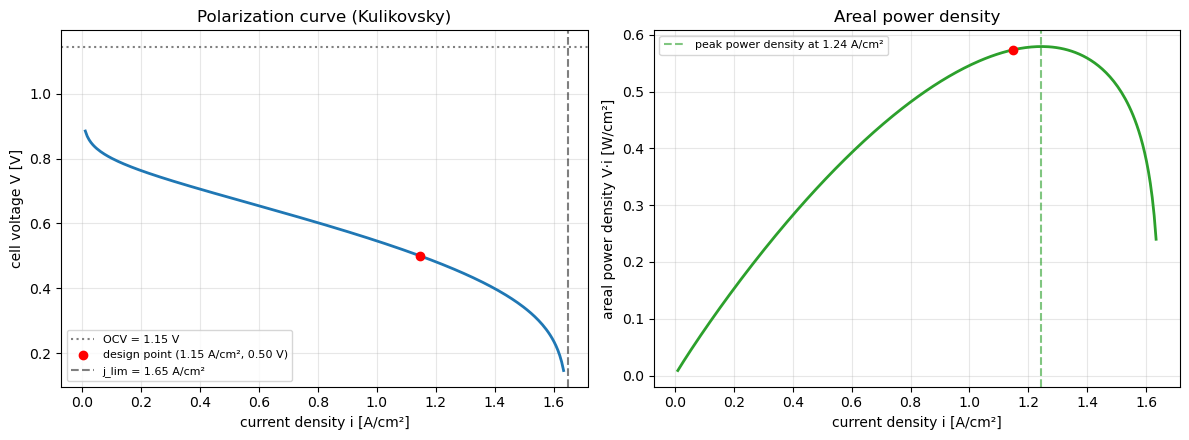

The design sits at 0.57 W/cm², 99% of the peak power density — trading power density for efficiency.


In [2]:
i = np.linspace(0.01, fc.j_lim * 0.99, 250)
V = np.array([fc.PolarizationCurve(ii, fc.Target_Press) for ii in i])
Pd = V * i

fig, (axV, axP) = plt.subplots(1, 2, figsize=(12, 4.5))
axV.plot(i, V, lw=2)
axV.axhline(fc.Voc, ls=":", c="gray", label=f"OCV = {fc.Voc:.2f} V")
axV.scatter([fc.i_max_density], [fc.V_cell_design], c="red", zorder=5,
            label=f"design point ({fc.i_max_density:.2f} A/cm², {fc.V_cell_design:.2f} V)")
axV.axvline(fc.j_lim, ls="--", c="k", alpha=0.5, label=f"j_lim = {fc.j_lim} A/cm²")
axV.set_xlabel("current density i [A/cm²]"); axV.set_ylabel("cell voltage V [V]")
axV.set_title("Polarization curve (Kulikovsky)"); axV.legend(fontsize=8)

axP.plot(i, Pd, lw=2, c="tab:green")
axP.scatter([fc.i_max_density], [fc.V_cell_design * fc.i_max_density], c="red", zorder=5)
axP.axvline(i[np.argmax(Pd)], ls="--", c="tab:green", alpha=0.6,
            label=f"peak power density at {i[np.argmax(Pd)]:.2f} A/cm²")
axP.set_xlabel("current density i [A/cm²]"); axP.set_ylabel("areal power density V·i [W/cm²]")
axP.set_title("Areal power density"); axP.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"The design sits at {fc.V_cell_design*fc.i_max_density:.2f} W/cm², "
      f"{100*fc.V_cell_design*fc.i_max_density/Pd.max():.0f}% of the peak power density — "
      "trading power density for efficiency.")

## 2 · System efficiency, including the auxiliaries

The **cell voltage efficiency** (referenced to the HHV thermoneutral voltage ≈ 1.48 V) is the
clean upper bound. The **net system efficiency** is lower: the air-system compressor and the fixed
auxiliaries (`Fixed_Aux_Load`) draw a slice of the gross power. That slice grows with altitude,
because the ambient pressure falls and the compressor must work harder to hold the cathode
pressure — so the same cell is *less* efficient at cruise than at sea level.

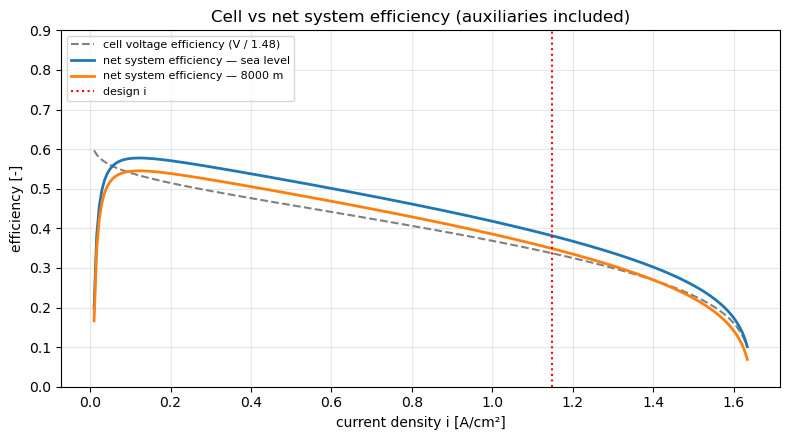

The gap between the dashed (cell) and solid (system) curves is the balance-of-plant + auxiliary draw; the sea-level/8000 m gap is the extra compressor work at altitude.


In [3]:
E_thermo = fc.DELTA_H_REACT / (2 * fc.FARADAY_CONST)        # ~1.48 V (HHV thermoneutral)
eta_voltage = V / E_thermo
eta_sl = np.array([fc.ComputeSystemEfficiency(ii, 0) for ii in i])
eta_cr = np.array([fc.ComputeSystemEfficiency(ii, 8000) for ii in i])

fig, ax = plt.subplots()
ax.plot(i, eta_voltage, ls="--", c="gray", label="cell voltage efficiency (V / 1.48)")
ax.plot(i, eta_sl, lw=2, label="net system efficiency — sea level")
ax.plot(i, eta_cr, lw=2, label="net system efficiency — 8000 m")
ax.axvline(fc.i_max_density, ls=":", c="red", label="design i")
ax.set_xlabel("current density i [A/cm²]"); ax.set_ylabel("efficiency [-]")
ax.set_ylim(0, 0.9); ax.set_title("Cell vs net system efficiency (auxiliaries included)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print("The gap between the dashed (cell) and solid (system) curves is the balance-of-plant + "
      "auxiliary draw; the sea-level/8000 m gap is the extra compressor work at altitude.")

## 3 · Weight breakdown — aircraft and fuel-cell system

Sizing the hydrogen aircraft closes the take-off weight over the structure, the **fuel-cell
system**, the usable **hydrogen**, the **cryogenic tank**, and the **cooling** (heat exchanger),
plus payload, crew and reserve. The fuel-cell system itself splits into the **stack**, the
**balance of plant** (here as heavy as the stack — `BoP Mass Ratio = 1.0` for this model), the
**power management** and the **electric motor**.

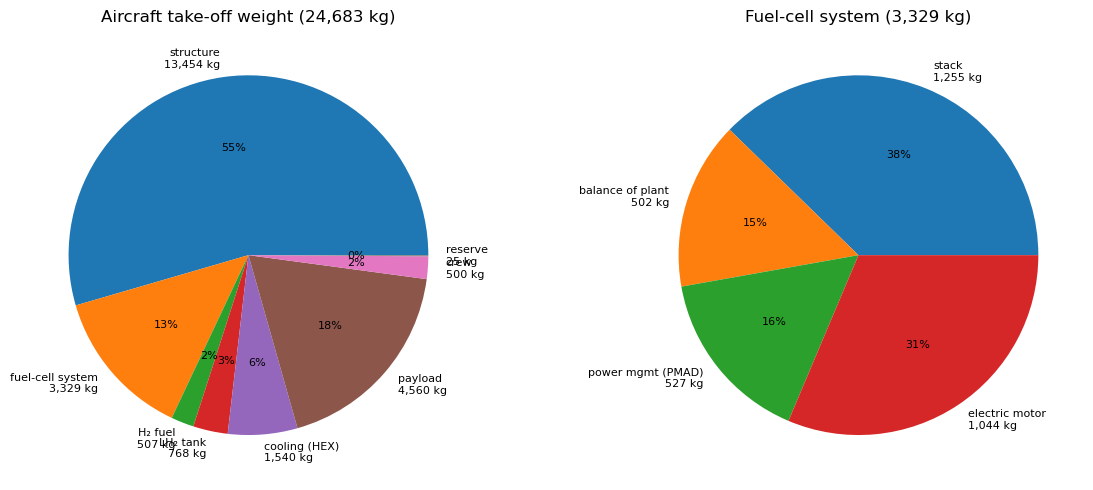

In [4]:
w = ac.weight
ac_parts = {
    "structure": w.WStructure, "fuel-cell system": w.WPT, "H₂ fuel": w.WH2_Fuel,
    "LH₂ tank": w.WTank, "cooling (HEX)": w.WHeat_Exchanger,
    "payload": w.WPayload, "crew": w.WCrew, "reserve": w.final_reserve,
}
# Fuel-cell system sub-split (recovered from the sizing relations in _size_stack):
M_PM = fc.P_fc_rated / 10000.0
M_EM = w.WElectric
M_stack = (w.WThermal - M_PM) / (1.0 + fc.BoP_Mass_Ratio)
M_BoP = M_stack * fc.BoP_Mass_Ratio
fc_parts = {"stack": M_stack, "balance of plant": M_BoP,
            "power mgmt (PMAD)": M_PM, "electric motor": M_EM}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))
a1.pie(ac_parts.values(), labels=[f"{k}\n{v:,.0f} kg" for k, v in ac_parts.items()],
       autopct="%1.0f%%", textprops={"fontsize": 8})
a1.set_title(f"Aircraft take-off weight ({w.WTO:,.0f} kg)")
a2.pie(fc_parts.values(), labels=[f"{k}\n{v:,.0f} kg" for k, v in fc_parts.items()],
       autopct="%1.0f%%", textprops={"fontsize": 8})
a2.set_title(f"Fuel-cell system ({fc.Weight:,.0f} kg)")
plt.tight_layout(); plt.show()

## 4 · How the aircraft varies with `V_cell` — is there an optimum?

A higher design cell voltage makes the cell *more efficient* — but far *less power-dense*, so the
stack needs much more area and gets heavier. In a coupled aircraft this heavier stack **snowballs**:
a heavier aircraft needs more power, hence even more stack and — perhaps surprisingly — even *more*
hydrogen. So the take-off weight has a minimum at a **low-to-moderate** design voltage; below it the
current density runs into the flooding limit, above it the mass snowballs.

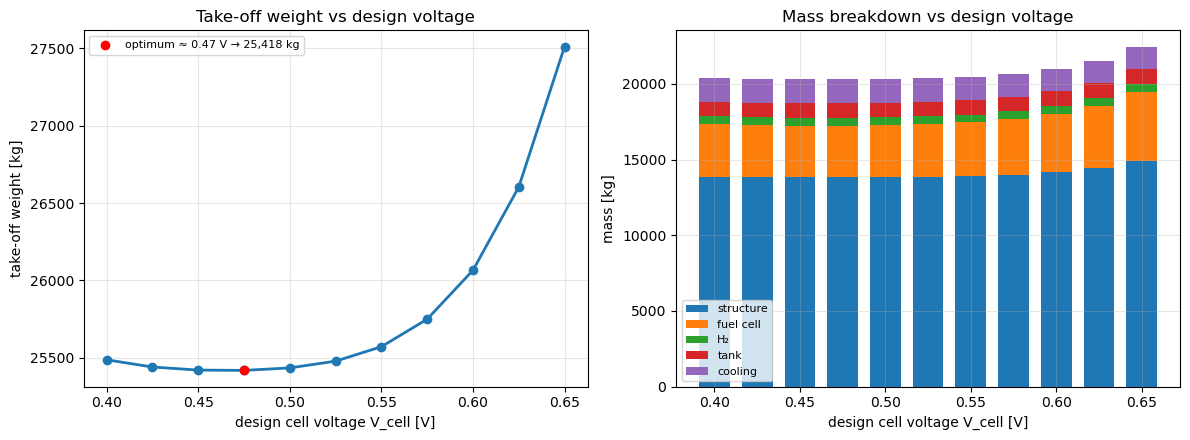

Optimum design voltage ≈ 0.47 V (min WTO). Note the H₂ mass *rises* with V_cell above the optimum — the stack-mass snowball outweighs the per-cell efficiency gain.


In [5]:
Vs = np.round(np.arange(0.40, 0.66, 0.025), 3)
WTOs, H2s, WPTs = [], [], []
breakdown = {k: [] for k in ["structure", "fuel cell", "H₂", "tank", "cooling"]}
for Vd in Vs:
    cfg = common.hydrogen_config(tank=False); cfg.energy.v_cell_design = float(Vd)
    try:
        a = pg.build_aircraft(); a.configure(cfg); wv = a.weight
        WTOs.append(wv.WTO); H2s.append(wv.WH2_Fuel); WPTs.append(wv.WPT)
        breakdown["structure"].append(wv.WStructure); breakdown["fuel cell"].append(wv.WPT)
        breakdown["H₂"].append(wv.WH2_Fuel); breakdown["tank"].append(wv.WTank)
        breakdown["cooling"].append(wv.WHeat_Exchanger)
    except Exception:
        for L in (WTOs, H2s, WPTs): L.append(np.nan)
        for k in breakdown: breakdown[k].append(np.nan)
WTOs = np.array(WTOs); i_opt = int(np.nanargmin(WTOs))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.plot(Vs, WTOs, "-o", lw=2)
a1.scatter([Vs[i_opt]], [WTOs[i_opt]], c="red", zorder=5,
           label=f"optimum ≈ {Vs[i_opt]:.2f} V → {WTOs[i_opt]:,.0f} kg")
a1.set_xlabel("design cell voltage V_cell [V]"); a1.set_ylabel("take-off weight [kg]")
a1.set_title("Take-off weight vs design voltage"); a1.legend(fontsize=8)
bottom = np.zeros(len(Vs))
for k, vals in breakdown.items():
    a2.bar(Vs, vals, width=0.018, bottom=bottom, label=k); bottom += np.nan_to_num(vals)
a2.set_xlabel("design cell voltage V_cell [V]"); a2.set_ylabel("mass [kg]")
a2.set_title("Mass breakdown vs design voltage"); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"Optimum design voltage ≈ {Vs[i_opt]:.2f} V (min WTO). Note the H₂ mass *rises* with V_cell "
      "above the optimum — the stack-mass snowball outweighs the per-cell efficiency gain.")

## 5 · Impact of the balance of plant

The balance of plant (humidifiers, pumps, valves, controls, the air-system hardware) is charged as
a multiple of the stack mass (`BoP Mass Ratio`). For this baseline it equals the stack itself, so
it is a *first-order* lever on the design. Halving it visibly lightens the aircraft.

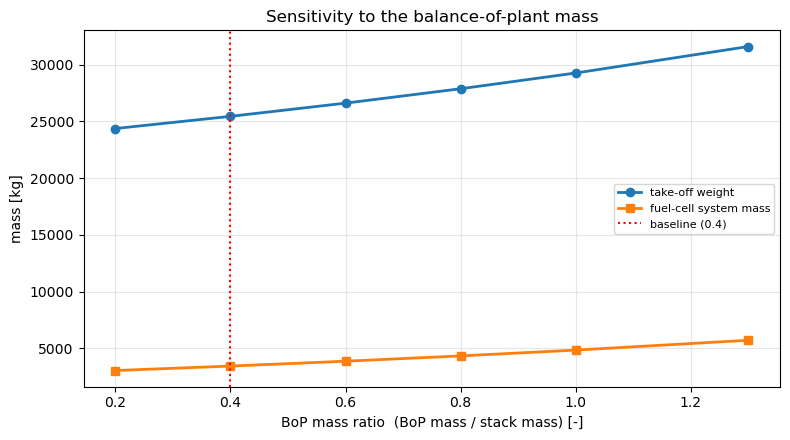

In [6]:
bops = [0.2, 0.4, 0.6, 0.8, 1.0, 1.3]
wto_b, wpt_b = [], []
for r in bops:
    cfg = common.hydrogen_config(tank=False); cfg.energy.bop_mass_ratio = r
    res, ok, _ = safe_design(cfg)
    wto_b.append(res.WTO if ok else np.nan); wpt_b.append(res.WPT if ok else np.nan)

fig, ax = plt.subplots()
ax.plot(bops, wto_b, "-o", lw=2, label="take-off weight")
ax.plot(bops, wpt_b, "-s", lw=2, label="fuel-cell system mass")
ax.axvline(fc.BoP_Mass_Ratio, ls=":", c="red", label=f"baseline ({fc.BoP_Mass_Ratio})")
ax.set_xlabel("BoP mass ratio  (BoP mass / stack mass) [-]"); ax.set_ylabel("mass [kg]")
ax.set_title("Sensitivity to the balance-of-plant mass"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6 · Impact of the compressor work

The cathode is held at `Target_Press`; the air system compresses ambient air up to it and recovers
some energy in a turbine. As altitude rises the ambient pressure falls, the pressure ratio grows,
and the **net compressor power** climbs — a parasitic load that eats into the net efficiency.

There is also a **design trade-off**: a higher cathode pressure improves the polarization (more
oxygen → higher voltage) but costs more compressor work. The right panel shows the polarization at
three cathode pressures.

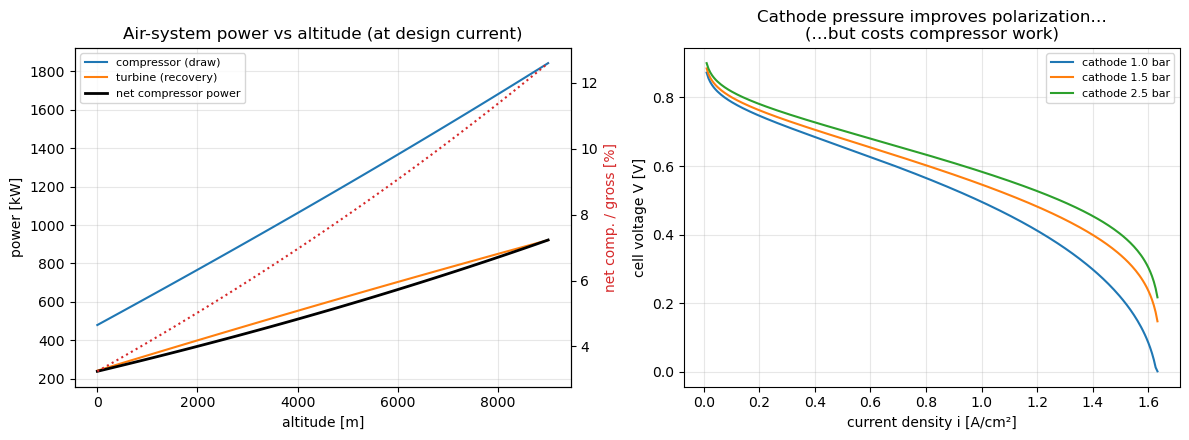

In [7]:
alts = np.linspace(0, 9000, 40)
I_des = fc.i_max_density * fc.A_cell_reale          # total stack current at the design point
comp, turb, net, frac = [], [], [], []
for h in alts:
    Pa, Ta = fc._get_env(h)
    cn, c, t = fc._compute_air_system_power(Pa, Ta, I_des)
    comp.append(c/1e3); turb.append(t/1e3); net.append(cn/1e3)
    P_gross = fc.N_cells * fc.PolarizationCurve(fc.i_max_density, fc.Target_Press) * I_des
    frac.append(100 * cn / P_gross)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.plot(alts, comp, label="compressor (draw)")
a1.plot(alts, turb, label="turbine (recovery)")
a1.plot(alts, net, lw=2, c="k", label="net compressor power")
a1.set_xlabel("altitude [m]"); a1.set_ylabel("power [kW]")
a1.set_title("Air-system power vs altitude (at design current)")
a1b = a1.twinx(); a1b.plot(alts, frac, ls=":", c="tab:red"); a1b.set_ylabel("net comp. / gross [%]", color="tab:red")
a1b.grid(False); a1.legend(fontsize=8, loc="upper left")

for p_bar in (1.0, 1.5, 2.5):
    Vp = [fc.PolarizationCurve(ii, p_bar*1e5) for ii in i]
    a2.plot(i, Vp, label=f"cathode {p_bar:.1f} bar")
a2.set_xlabel("current density i [A/cm²]"); a2.set_ylabel("cell voltage V [V]")
a2.set_title("Cathode pressure improves polarization…\n(…but costs compressor work)")
a2.legend(fontsize=8); plt.tight_layout(); plt.show()

## 7 · The cell operating point along the mission

We walk the converged mission and ask the fuel cell for its operating point at every instant. The
current density and cell voltage swing with the propulsive demand and the altitude lapse: high
current (low voltage) on the climb, low current (high voltage, efficient) in cruise. The right
panel drops those operating points onto the polarization curve.

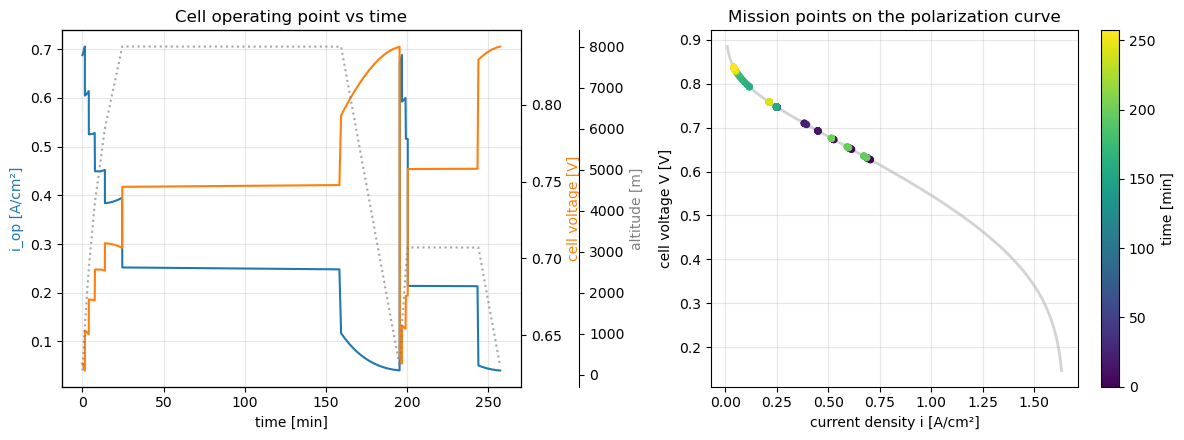

Cell efficiency over the mission: 0.48 (climb) to 0.56 (cruise).


In [8]:
m = ac.mission
t_all = np.concatenate([s.t for s in m.integral_solution])
beta_all = np.concatenate([s.y[-1] for s in m.integral_solution])
sel = slice(None, None, max(1, len(t_all)//120))
t_s, beta_s = t_all[sel], beta_all[sel]

iop, vop, etas, Qs, pcomp, alt_s = [], [], [], [], [], []
for tt, b in zip(t_s, beta_s):
    alt = float(m.profile.Altitude(tt)); vel = float(m.profile.Velocity(tt))
    Pp = ac.weight.WTO * ac.performance.PoWTO(ac.DesignWTOoS, b, m.profile.PowerExcess(tt),
                                              1, alt, m.DISA, vel, "TAS")
    fc.ComputePRatio(alt, vel, Pp)
    iop.append(fc.i_op_last); vop.append(fc.v_cell_last); etas.append(fc.eta_fcs_last)
    Qs.append(fc.Q_thermal); pcomp.append(fc.P_comp_net_last); alt_s.append(alt)
t_min = t_s / 60.0; iop = np.array(iop); vop = np.array(vop)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.plot(t_min, iop, c="tab:blue", label="current density i_op")
a1.set_xlabel("time [min]"); a1.set_ylabel("i_op [A/cm²]", color="tab:blue")
a1b = a1.twinx(); a1b.plot(t_min, vop, c="tab:orange"); a1b.set_ylabel("cell voltage [V]", color="tab:orange"); a1b.grid(False)
a1c = a1.twinx(); a1c.spines["right"].set_position(("outward", 42))
a1c.plot(t_min, alt_s, c="gray", ls=":", alpha=0.7); a1c.set_ylabel("altitude [m]", color="gray"); a1c.grid(False)
a1.set_title("Cell operating point vs time")

a2.plot(i, V, c="lightgray", lw=2, zorder=1)
sc = a2.scatter(iop, vop, c=t_min, cmap="viridis", s=18, zorder=2)
a2.set_xlabel("current density i [A/cm²]"); a2.set_ylabel("cell voltage V [V]")
a2.set_title("Mission points on the polarization curve")
plt.colorbar(sc, ax=a2, label="time [min]"); plt.tight_layout(); plt.show()
print(f"Cell efficiency over the mission: {np.nanmin(etas):.2f} (climb) to {np.nanmax(etas):.2f} (cruise).")

## 8 · Stack heat release over time

Every volt of overpotential becomes heat. The stack heat `Q_thermal` peaks on the climb (highest
current) and is the load the cooling system (the HEX mass in §3) must reject — for a fuel cell this
is demanding, because the stack runs *cool* (~80 °C) so the temperature difference to ambient is
small. The hydrogen mass flow tracks the power demand.

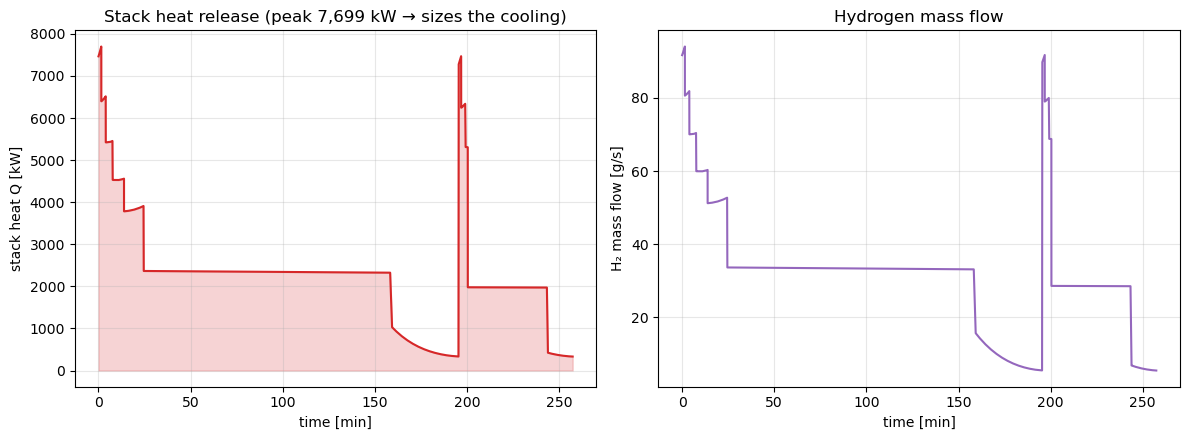

In [9]:
Qs = np.array(Qs)
# Hydrogen mass flow straight from the cell operating point: m_dot = N_cells·I / (2F) · M_H2,
# at the same sampled mission points as the walk above. (Differentiating the cumulative energy
# state instead would divide by zero at the duplicated segment-boundary times.)
I_tot = np.array(iop) * fc.A_cell_reale
mdot = fc.N_cells * I_tot / (2 * fc.FARADAY_CONST) * fc.MOLAR_MASS_H2     # kg/s
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.plot(t_min, Qs/1e3, c="tab:red"); a1.fill_between(t_min, Qs/1e3, alpha=0.2, color="tab:red")
a1.set_xlabel("time [min]"); a1.set_ylabel("stack heat Q [kW]")
a1.set_title(f"Stack heat release (peak {np.nanmax(Qs)/1e3:,.0f} kW → sizes the cooling)")
a2.plot(t_min, mdot * 1e3, c="tab:purple")
a2.set_xlabel("time [min]"); a2.set_ylabel("H₂ mass flow [g/s]")
a2.set_title("Hydrogen mass flow"); plt.tight_layout(); plt.show()

## 9 · LH₂ tank thermodynamics over time

The cryogenic tank self-pressurises as heat leaks in; it vents when it reaches `P_max` and the
heater kicks in at `P_min`. `compute_tank_history` walks the flown mission and advances the tank
state (pressure, stored mass, vent flow, heat in/out).

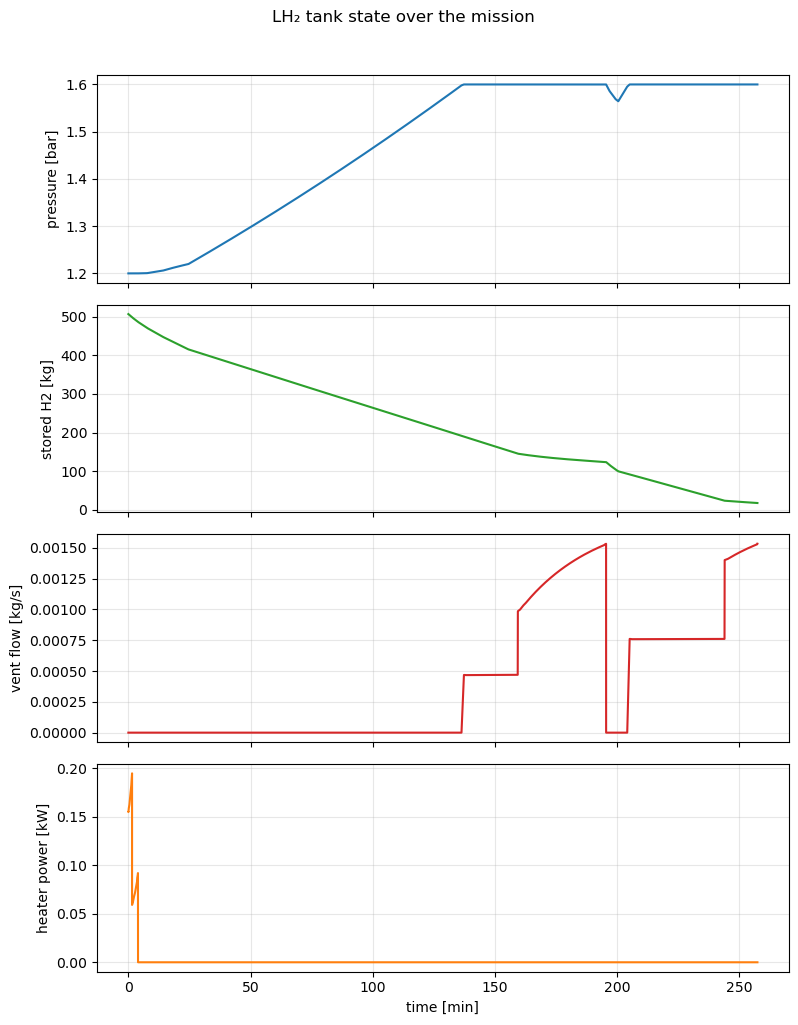

Tank pressure spanned 1.20–1.60 bar; vented 6.5 kg of H₂ over the mission.


In [10]:
pp.compute_tank_history(ac)
axes = pp.plot_tank_state(ac)
fig = axes[0].figure if hasattr(axes[0], "figure") else plt.gcf()
fig.suptitle("LH₂ tank state over the mission", y=1.02)
plt.tight_layout(); plt.show()
h = ac.tank.history
print(f"Tank pressure spanned {min(h['P']):.2f}–{max(h['P']):.2f} bar; "
      f"vented {h['m_vent_cum'][-1]:.1f} kg of H₂ over the mission.")

## 10 · Extra: the gross-vs-net power split along the mission

Finally, the parasitics in context: the gross stack power must cover the propulsive demand (after
the electric chain), the **net compressor** draw and the **fixed auxiliaries**. The gap between
gross and net is the price of running the system.

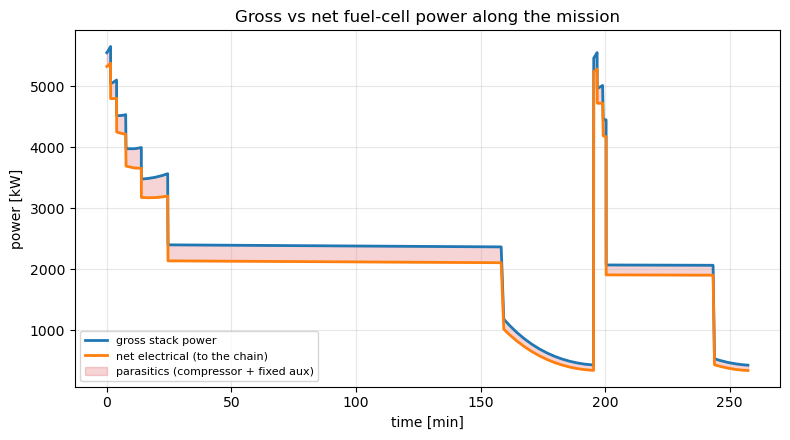

In [11]:
P_fixed = fc.P_fc_rated * fc.Fixed_Aux_Load
pgross = []
for tt, b in zip(t_s, beta_s):
    alt = float(m.profile.Altitude(tt)); vel = float(m.profile.Velocity(tt))
    Pp = ac.weight.WTO * ac.performance.PoWTO(ac.DesignWTOoS, b, m.profile.PowerExcess(tt),
                                              1, alt, m.DISA, vel, "TAS")
    fc.ComputePRatio(alt, vel, Pp); pgross.append(fc.P_gross_last)
pgross = np.array(pgross); pcomp = np.array(pcomp)
fig, ax = plt.subplots()
ax.plot(t_min, pgross/1e3, lw=2, label="gross stack power")
ax.plot(t_min, (pgross - pcomp - P_fixed)/1e3, lw=2, label="net electrical (to the chain)")
ax.fill_between(t_min, (pgross-pcomp-P_fixed)/1e3, pgross/1e3, alpha=0.2, color="tab:red",
                label="parasitics (compressor + fixed aux)")
ax.set_xlabel("time [min]"); ax.set_ylabel("power [kW]")
ax.set_title("Gross vs net fuel-cell power along the mission"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Takeaways

- The **polarization curve** sets the cell's voltage–current trade; the **design voltage** picks a
  point on it, trading power density (stack mass) for efficiency (fuel).
- The **net system efficiency** is well below the cell voltage efficiency because of the
  **balance-of-plant** and **compressor** parasitics, and it *degrades with altitude*.
- In the **coupled aircraft**, a higher design voltage is *not* better: the heavier stack
  snowballs and even increases the hydrogen burnt, so the take-off weight has an optimum at a
  **low-to-moderate** design voltage.
- The **balance of plant** and the **cooling** are first-order masses for a fuel-cell aircraft —
  more so than for a gas turbine — because the stack is heavy *and* runs cool.
- Along the mission the cell sweeps from **high-current/low-voltage** (climb) to
  **low-current/high-voltage** (cruise); the **stack heat** peaks on the climb and sizes the HEX;
  the **LH₂ tank** self-pressurises and vents.

Try it: change `Model` to `'PEMFC_HighPerformance'` in `common._energy_hydrogen`, or raise the
cathode `Target_Press`, and re-run — watch the polarization, the optimum voltage and the weight
breakdown move.